# Pure T Cell scANVI Semi-supervised Learning

**Objective**: Fine-tune scVI model with starCAT annotations using scANVI

**Workflow**:
1. Load scVI-integrated data with starCAT annotations
2. Load pre-trained scVI model
3. Initialize scANVI from scVI model
4. Train scANVI with cell type labels
5. Compare scVI vs scANVI latent spaces
6. Evaluate integration quality
7. Save results

**Expected cell types** (from starCAT):
- CD4 subtypes: CD4_CM, CD4_Naive, CD4_EM
- CD8 subtypes: CD8_CM, CD8_Naive, CD8_TEMRA, CD8_EM
- Other: Treg, gdT, MAIT

**Key advantage of scANVI**:
- Better latent space for cell type separation
- Can predict cell types for new data
- Improved batch correction with label guidance

---
## Step 1: Import Libraries

In [21]:
import sys
import os
from pathlib import Path
import warnings
import time
from datetime import datetime

import numpy as np
import pandas as pd
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns

# Single-cell analysis
import scanpy as sc
import scvi

# For integration metrics (optional, install if needed: pip install scib-metrics)
try:
    from scib_metrics.benchmark import Benchmarker
    SCIB_AVAILABLE = True
except ImportError:
    print("scib-metrics not available. Will skip integration metrics.")
    SCIB_AVAILABLE = False

warnings.filterwarnings('ignore')

# Check versions
print(f"scanpy: {sc.__version__}")
print(f"scvi-tools: {scvi.__version__}")

# Check GPU
import torch
gpu_available = torch.cuda.is_available()
print(f"\nGPU available: {gpu_available}")
if gpu_available:
    print(f"GPU device: {torch.cuda.get_device_name(0)}")

# Plot settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)
plt.rcParams['figure.figsize'] = (8, 6)

print("\n✓ Libraries loaded")

scib-metrics not available. Will skip integration metrics.
scanpy: 1.11.5
scvi-tools: 1.3.3

GPU available: True
GPU device: Tesla V100-SXM2-16GB

✓ Libraries loaded


---
## Step 2: Configuration

In [22]:
# ==================== Configuration ====================

# Random seed
import random
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print(f"✓ Random seed: {RANDOM_SEED}")

# ========== Input/Output ==========
# Input: starCAT annotated data (output from starCAT pipeline)
INPUT_H5AD = "/home/h2048/data/py/1204/Tcell_pure_scvi/starcat_analysis/adata_tcell_scvi_starcat_annotated.h5ad"

# Pre-trained scVI model directory
SCVI_MODEL_DIR = "/home/h2048/data/py/1204/Tcell_pure_scvi/scvi_model"

# Output directory for scANVI results
OUTPUT_DIR = "/home/h2048/data/py/1204/Tcell_scANVI"

# ========== scANVI Configuration ==========
# Cell type labels from starCAT
LABELS_KEY = "Multinomial_Label"  # starCAT annotation column

# Unlabeled category (if any cells lack labels)
UNLABELED_CATEGORY = "Unknown"  # Cells with this label will be predicted

# Batch key (for integration metrics)
BATCH_KEY = "dataset"

# ========== Training Parameters ==========
MAX_EPOCHS_SCANVI = 150      # Fine-tuning epochs (less than scVI)
EARLY_STOPPING = True        # Auto-stop when converged
LEARNING_RATE = 5e-4         # Slightly lower than scVI (1e-3)
N_SAMPLES_PER_LABEL = 100    # Balanced sampling per cell type

# ========== UMAP Parameters ==========
UMAP_MIN_DIST = 0.2
UMAP_SPREAD = 1.5
UMAP_N_NEIGHBORS = 30

# ========== Visualization ==========
DPI = 300
FIGURE_FORMAT = "pdf"

# Marker genes for validation
MARKER_GENES = {
    'Pan_T': ['CD3D', 'CD3E', 'CD3G'],
    'CD4': ['CD4', 'IL7R'],
    'CD8': ['CD8A', 'CD8B'],
    'Naive': ['CCR7', 'SELL', 'LEF1', 'TCF7'],
    'Memory': ['IL7R', 'CD44'],
    'Effector': ['GZMA', 'GZMB', 'GZMK', 'PRF1'],
    'Treg': ['FOXP3', 'IL2RA', 'CTLA4'],
    'Exhaustion': ['PDCD1', 'LAG3', 'TIGIT']
}

# Create directories
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

fig_dir = output_dir / "figures"
fig_dir.mkdir(exist_ok=True)

scanvi_model_dir = output_dir / "scanvi_model"
scanvi_model_dir.mkdir(exist_ok=True)

print("\n✓ Configuration loaded")
print(f"  Input: {INPUT_H5AD}")
print(f"  scVI model: {SCVI_MODEL_DIR}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Labels: {LABELS_KEY}")
print(f"  Max epochs: {MAX_EPOCHS_SCANVI}")

✓ Random seed: 42

✓ Configuration loaded
  Input: /home/h2048/data/py/1204/Tcell_pure_scvi/starcat_analysis/adata_tcell_scvi_starcat_annotated.h5ad
  scVI model: /home/h2048/data/py/1204/Tcell_pure_scvi/scvi_model
  Output: /home/h2048/data/py/1204/Tcell_scANVI
  Labels: Multinomial_Label
  Max epochs: 150


---
## Step 3: Load Data and Inspect Labels

In [23]:
print("\n" + "="*70)
print("Step 3: Loading starCAT Annotated Data")
print("="*70)

# Load
adata = sc.read_h5ad(INPUT_H5AD)
print(f"\nLoaded: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes")

# Check labels
if LABELS_KEY not in adata.obs.columns:
    raise KeyError(
        f"Labels key '{LABELS_KEY}' not found in adata.obs\n"
        f"Available columns: {list(adata.obs.columns)[:20]}"
    )

print(f"\n✓ Cell type labels found: {LABELS_KEY}")

# Display label distribution
label_counts = adata.obs[LABELS_KEY].value_counts()
print(f"\nCell type distribution ({len(label_counts)} types):")
for label, count in label_counts.items():
    pct = count / len(adata) * 100
    print(f"  {label}: {count:,} cells ({pct:.1f}%)")

# Check for unlabeled cells
has_unlabeled = (adata.obs[LABELS_KEY] == UNLABELED_CATEGORY).any()
if has_unlabeled:
    n_unlabeled = (adata.obs[LABELS_KEY] == UNLABELED_CATEGORY).sum()
    print(f"\n⚠️  Found {n_unlabeled:,} unlabeled cells ('{UNLABELED_CATEGORY}')")
    print(f"  scANVI will predict labels for these cells")
else:
    print(f"\n✓ All cells have labels (no '{UNLABELED_CATEGORY}')")

# Check batch info
if BATCH_KEY in adata.obs.columns:
    n_batches = adata.obs[BATCH_KEY].nunique()
    print(f"\n✓ Batch info: {BATCH_KEY} ({n_batches} batches)")
else:
    print(f"\n⚠️  Batch key '{BATCH_KEY}' not found")

# Check for UMAP
if 'X_umap' in adata.obsm:
    print(f"\n✓ UMAP coordinates available")
else:
    print(f"\n⚠️  No UMAP found, will compute later")

# Check for scVI latent
if 'X_scvi' in adata.obsm:
    print(f"✓ scVI latent space: {adata.obsm['X_scvi'].shape}")
else:
    print(f"⚠️  No scVI latent space found")

print("\n✓ Data inspection complete")


Step 3: Loading starCAT Annotated Data

Loaded: 32,731 cells × 34,252 genes

✓ Cell type labels found: Multinomial_Label

Cell type distribution (10 types):
  CD8_CM: 7,931 cells (24.2%)
  CD4_CM: 7,582 cells (23.2%)
  CD4_EM: 4,919 cells (15.0%)
  CD4_Naive: 3,865 cells (11.8%)
  CD8_Naive: 2,996 cells (9.2%)
  gdT: 1,880 cells (5.7%)
  CD8_TEMRA: 1,711 cells (5.2%)
  CD8_EM: 857 cells (2.6%)
  Treg: 685 cells (2.1%)
  MAIT: 305 cells (0.9%)

✓ All cells have labels (no 'Unknown')

✓ Batch info: dataset (18 batches)

✓ UMAP coordinates available
✓ scVI latent space: (32731, 75)

✓ Data inspection complete


---
## Step 4: Visualize Pre-scANVI State

In [24]:
print("\n" + "="*70)
print("Step 4: Visualizing scVI Results (Before scANVI)")
print("="*70)

# Compute UMAP if not exists
if 'X_umap' not in adata.obsm:
    print("\nComputing UMAP from scVI latent space...")
    if 'X_scvi' in adata.obsm:
        sc.pp.neighbors(adata, use_rep='X_scvi', n_neighbors=UMAP_N_NEIGHBORS)
    else:
        sc.pp.neighbors(adata, n_neighbors=UMAP_N_NEIGHBORS)
    
    sc.tl.umap(adata, min_dist=UMAP_MIN_DIST, spread=UMAP_SPREAD)
    print("  ✓ UMAP computed")

# Plot current state
print("\nGenerating baseline plots...")


Step 4: Visualizing scVI Results (Before scANVI)

Generating baseline plots...


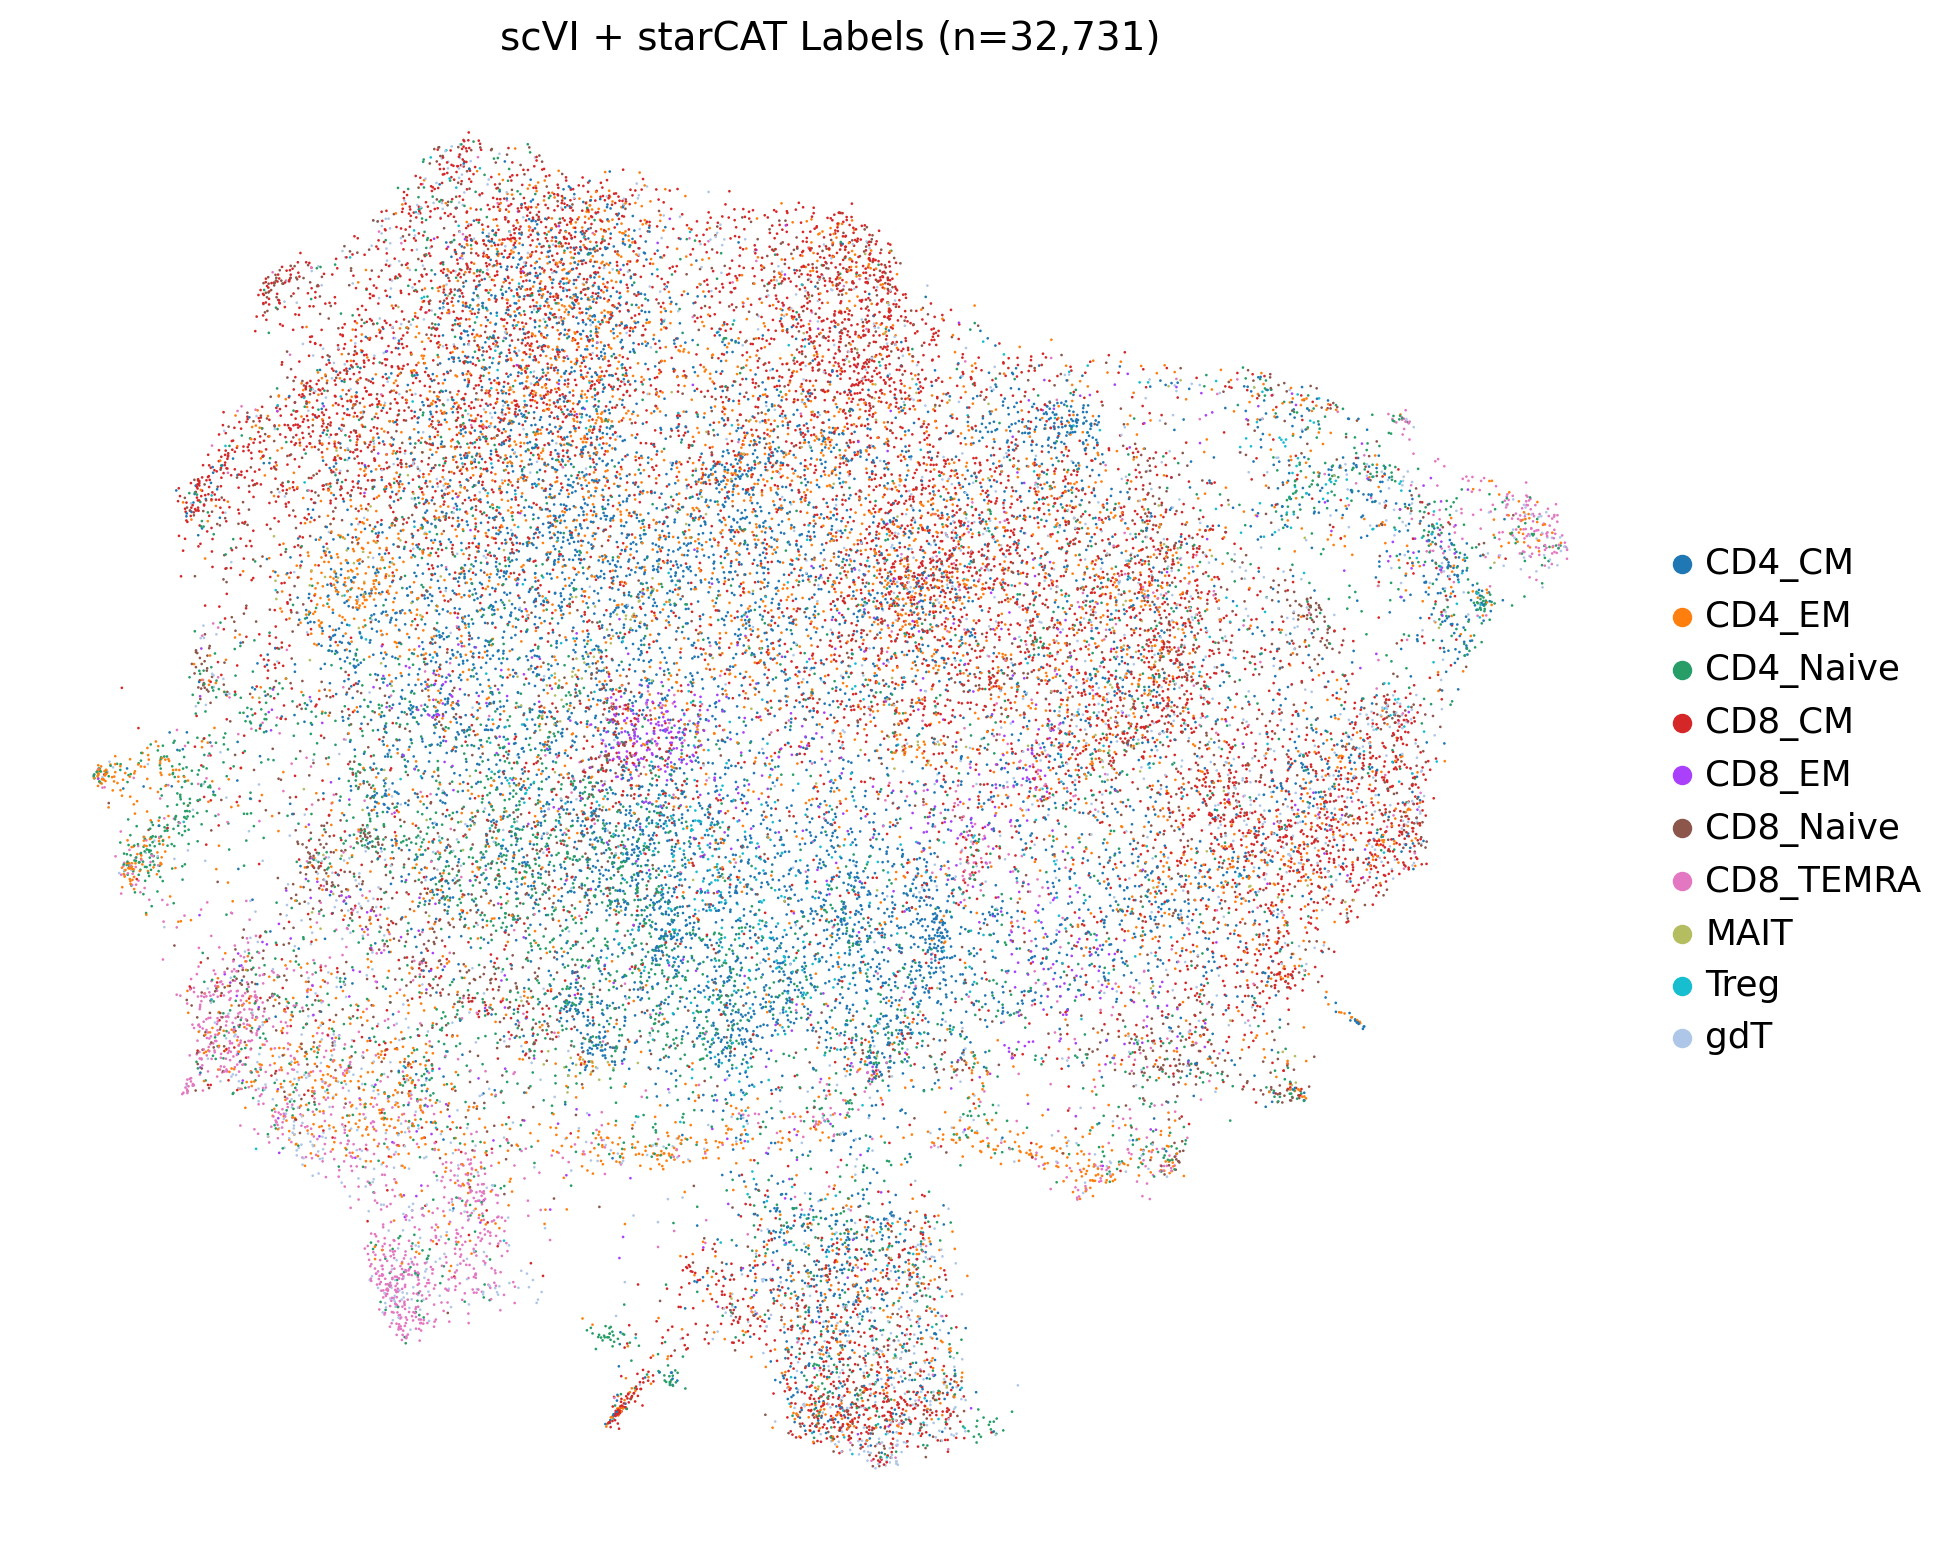

✓ Plot 1: scVI UMAP with starCAT labels


In [25]:
# Cell types on scVI UMAP
fig, ax = plt.subplots(figsize=(10, 8))

sc.pl.umap(
    adata,
    color=LABELS_KEY,
    ax=ax,
    show=False,
    legend_loc='right margin',
    frameon=False,
    title=f'scVI + starCAT Labels (n={len(adata):,})'
)

plt.tight_layout()
plt.savefig(fig_dir / f'umap_scVI_starcat_labels.{FIGURE_FORMAT}', 
            dpi=DPI, bbox_inches='tight')
plt.show()

print("✓ Plot 1: scVI UMAP with starCAT labels")

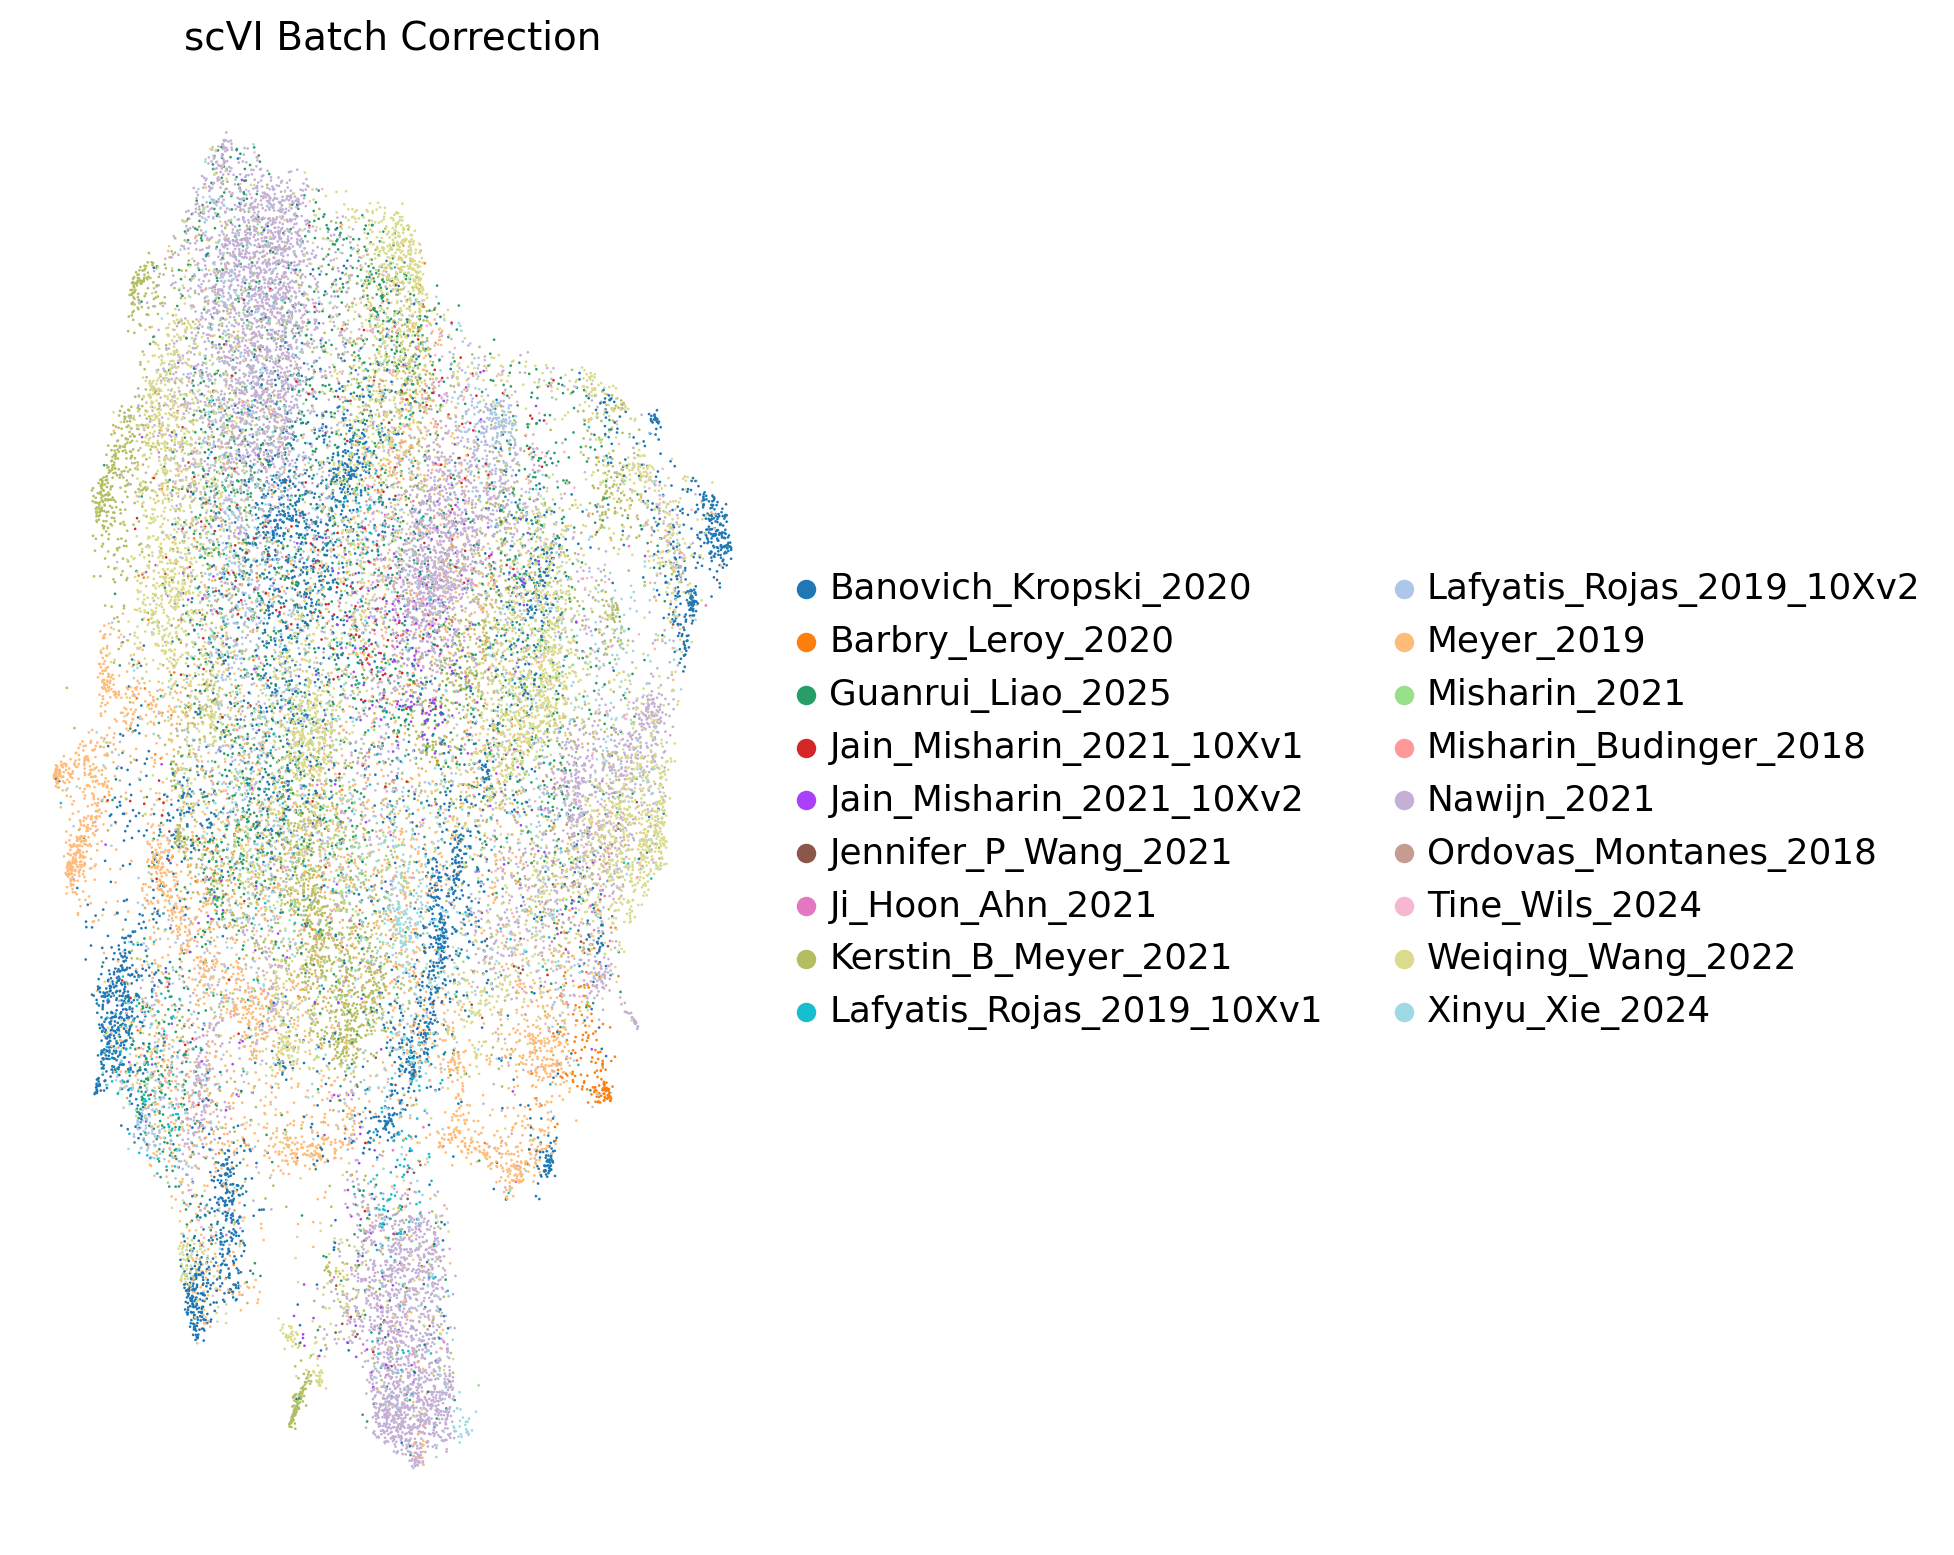

✓ Plot 2: scVI batch mixing

✓ Baseline visualization complete


In [26]:
# Batch distribution (if available)
if BATCH_KEY in adata.obs.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sc.pl.umap(
        adata,
        color=BATCH_KEY,
        ax=ax,
        show=False,
        legend_loc='right margin',
        frameon=False,
        title='scVI Batch Correction'
    )
    
    plt.tight_layout()
    plt.savefig(fig_dir / f'umap_scVI_batch.{FIGURE_FORMAT}', 
                dpi=DPI, bbox_inches='tight')
    plt.show()
    
    print("✓ Plot 2: scVI batch mixing")

print("\n✓ Baseline visualization complete")

---
## Step 5: Load Pre-trained scVI Model

In [27]:
print("\n" + "="*70)
print("Step 5: Loading Pre-trained scVI Model")
print("="*70)

scvi_model_path = Path(SCVI_MODEL_DIR)

if not scvi_model_path.exists():
    raise FileNotFoundError(
        f"scVI model not found: {scvi_model_path}\n"
        f"Please train scVI first or update SCVI_MODEL_DIR"
    )

print(f"\nLoading scVI model from: {scvi_model_path}")

try:
    # First setup anndata for scVI
    # This must match the original scVI setup
    print("\nSetting up AnnData for scVI...")
    
    # Check if counts layer exists
    if 'counts' not in adata.layers:
        print("⚠️  'counts' layer not found, checking alternatives...")
        if adata.raw is not None:
            print("  Using .raw for counts")
            adata.layers['counts'] = adata.raw.X.copy()
        else:
            print("  ⚠️  Using .X (verify this is raw counts!)")
            adata.layers['counts'] = adata.X.copy()
    
    # Setup scVI
    scvi.model.SCVI.setup_anndata(
        adata,
        layer='counts',
        batch_key=BATCH_KEY if BATCH_KEY in adata.obs.columns else None
    )
    
    print("  ✓ AnnData setup complete")
    
    # Load model
    scvi_model = scvi.model.SCVI.load(scvi_model_path, adata)
    
    print(f"\n✓ scVI model loaded successfully")
    print(f"  Model type: {type(scvi_model).__name__}")
    print(f"  Latent dimensions: {scvi_model.module.n_latent}")
    print(f"  Training history: {len(scvi_model.history['elbo_train'])} epochs")
    
except Exception as e:
    print(f"\n✗ Error loading scVI model: {e}")
    print("\nTroubleshooting:")
    print("  1. Verify model path is correct")
    print("  2. Check if data matches training data")
    print("  3. Ensure scvi-tools version is compatible")
    raise

print("\n✓ Model loading complete")


Step 5: Loading Pre-trained scVI Model

Loading scVI model from: /home/h2048/data/py/1204/Tcell_pure_scvi/scvi_model

Setting up AnnData for scVI...
  ✓ AnnData setup complete
INFO     File /home/h2048/data/py/1204/Tcell_pure_scvi/scvi_model/model.pt already downloaded                      

✗ Error loading scVI model: Number of vars in `adata_target` not the same as source. Expected: 4000 Received: 34252

Troubleshooting:
  1. Verify model path is correct
  2. Check if data matches training data
  3. Ensure scvi-tools version is compatible


ValueError: Number of vars in `adata_target` not the same as source. Expected: 4000 Received: 34252

---
## Step 6: Initialize scANVI from scVI

In [ ]:
print("\n" + "="*70)
print("Step 6: Initializing scANVI from scVI Model")
print("="*70)

print(f"\nInitializing scANVI...")
print(f"  Labels key: {LABELS_KEY}")
print(f"  Unlabeled category: {UNLABELED_CATEGORY}")

try:
    # Initialize scANVI from trained scVI model
    # This transfers the learned representations to scANVI
    scanvi_model = scvi.model.SCANVI.from_scvi_model(
        scvi_model,
        adata=adata,
        labels_key=LABELS_KEY,
        unlabeled_category=UNLABELED_CATEGORY
    )
    
    print(f"\n✓ scANVI initialized successfully")
    print(f"  Model type: {type(scanvi_model).__name__}")
    print(f"  Latent dimensions: {scanvi_model.module.n_latent}")
    print(f"  Cell types: {scanvi_model.n_labels}")
    
    # Display cell type mapping
    print(f"\n  Cell type indices:")
    for idx, label in enumerate(scanvi_model.label_encoder_original.classes_):
        print(f"    {idx}: {label}")
    
except Exception as e:
    print(f"\n✗ Error initializing scANVI: {e}")
    print("\nCommon issues:")
    print("  1. Labels key not found in adata.obs")
    print("  2. Unlabeled category name conflicts with real labels")
    print("  3. scVI model and adata mismatch")
    raise

print("\n✓ Initialization complete")

---
## Step 7: Train scANVI

In [ ]:
print("\n" + "="*70)
print("Step 7: Training scANVI (Semi-supervised Fine-tuning)")
print("="*70)

print(f"\nTraining configuration:")
print(f"  Max epochs: {MAX_EPOCHS_SCANVI}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Samples per label: {N_SAMPLES_PER_LABEL}")
print(f"  Early stopping: {EARLY_STOPPING}")

print(f"\nStarting training...")
print(f"  (This will take 5-10 minutes for ~50k cells)")

start_time = time.time()

try:
    scanvi_model.train(
        max_epochs=MAX_EPOCHS_SCANVI,
        n_samples_per_label=N_SAMPLES_PER_LABEL,
        lr=LEARNING_RATE,
        early_stopping=EARLY_STOPPING,
        early_stopping_patience=45,
        plan_kwargs={'weight_decay': 1e-6}
    )
    
    elapsed = time.time() - start_time
    
    print(f"\n✓ Training completed in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"  Epochs trained: {len(scanvi_model.history['elbo_train'])}")
    print(f"  Final ELBO: {scanvi_model.history['elbo_train'][-1]:.2f}")
    
except Exception as e:
    print(f"\n✗ Training failed: {e}")
    raise

print("\n✓ Training complete")

---
## Step 8: Visualize Training History

In [ ]:
print("\n" + "="*70)
print("Step 8: Visualizing Training History")
print("="*70)

# Plot training curves
train_elbo = scanvi_model.history['elbo_train']
val_elbo = scanvi_model.history.get('elbo_validation', None)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full history
axes[0].plot(train_elbo, label='Training ELBO', linewidth=2)
if val_elbo is not None:
    axes[0].plot(val_elbo, label='Validation ELBO', linewidth=2, alpha=0.7)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('ELBO', fontsize=12)
axes[0].set_title('scANVI Training History', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Last 50 epochs
n_show = min(50, len(train_elbo))
axes[1].plot(range(len(train_elbo)-n_show, len(train_elbo)), 
             train_elbo[-n_show:], linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('ELBO', fontsize=12)
axes[1].set_title(f'Convergence Detail (Last {n_show} epochs)', 
                 fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / f'scanvi_training_history.{FIGURE_FORMAT}', 
            dpi=DPI, bbox_inches='tight')
plt.show()

print("✓ Training curves saved")

# Print convergence stats
print(f"\nConvergence statistics:")
print(f"  Initial ELBO: {train_elbo[0]:.2f}")
print(f"  Final ELBO: {train_elbo[-1]:.2f}")
print(f"  Improvement: {train_elbo[0] - train_elbo[-1]:.2f}")

if len(train_elbo) >= 50:
    elbo_50 = train_elbo[49]
    improvement_late = elbo_50 - train_elbo[-1]
    print(f"  Improvement after epoch 50: {improvement_late:.2f}")
    if improvement_late < 2:
        print(f"  → Fast convergence ✓")

print("\n✓ Training visualization complete")

---
## Step 9: Extract scANVI Latent Representation

In [ ]:
print("\n" + "="*70)
print("Step 9: Extracting scANVI Latent Space")
print("="*70)

print(f"\nExtracting latent representations...")

# Get scANVI latent space
SCANVI_LATENT_KEY = "X_scANVI"
adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata)

print(f"  ✓ scANVI latent: {adata.obsm[SCANVI_LATENT_KEY].shape}")

# Get predicted labels (for unlabeled cells)
print(f"\nPredicting cell types...")
predictions = scanvi_model.predict(adata)
adata.obs['scANVI_predicted'] = predictions

# Compare with original labels
if has_unlabeled:
    print(f"\n  Predictions for unlabeled cells:")
    unlabeled_mask = adata.obs[LABELS_KEY] == UNLABELED_CATEGORY
    pred_counts = adata.obs.loc[unlabeled_mask, 'scANVI_predicted'].value_counts()
    for pred, count in pred_counts.items():
        print(f"    {pred}: {count:,} cells")
else:
    # Check prediction accuracy
    accuracy = (adata.obs[LABELS_KEY] == adata.obs['scANVI_predicted']).mean()
    print(f"\n  ✓ Prediction accuracy: {accuracy*100:.2f}%")
    
    # Show mismatches
    mismatches = adata.obs[LABELS_KEY] != adata.obs['scANVI_predicted']
    if mismatches.any():
        print(f"  Mismatched cells: {mismatches.sum():,} ({mismatches.mean()*100:.2f}%)")

print("\n✓ Latent space extraction complete")

---
## Step 10: Compute scANVI UMAP

In [ ]:
print("\n" + "="*70)
print("Step 10: Computing scANVI UMAP")
print("="*70)

print(f"\nComputing neighbors from scANVI latent space...")
sc.pp.neighbors(adata, use_rep=SCANVI_LATENT_KEY, n_neighbors=UMAP_N_NEIGHBORS)

print(f"Computing UMAP...")
# Store old UMAP
if 'X_umap' in adata.obsm:
    adata.obsm['X_umap_scVI'] = adata.obsm['X_umap'].copy()

sc.tl.umap(adata, min_dist=UMAP_MIN_DIST, spread=UMAP_SPREAD)

# Rename to scANVI UMAP
adata.obsm['X_umap_scANVI'] = adata.obsm['X_umap'].copy()

print(f"\n✓ scANVI UMAP computed")
print(f"  Available UMAPs:")
if 'X_umap_scVI' in adata.obsm:
    print(f"    X_umap_scVI: scVI-based UMAP")
print(f"    X_umap_scANVI: scANVI-based UMAP (current)")

---
## Step 11: Compare scVI vs scANVI

In [ ]:
print("\n" + "="*70)
print("Step 11: Comparing scVI vs scANVI")
print("="*70)

print("\nGenerating comparison plots...")

In [ ]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# scVI
if 'X_umap_scVI' in adata.obsm:
    adata.obsm['X_umap'] = adata.obsm['X_umap_scVI']
    sc.pl.umap(
        adata,
        color=LABELS_KEY,
        ax=axes[0],
        show=False,
        legend_loc='on data',
        legend_fontsize=6,
        frameon=False,
        title='scVI (Unsupervised)'
    )

# scANVI
adata.obsm['X_umap'] = adata.obsm['X_umap_scANVI']
sc.pl.umap(
    adata,
    color=LABELS_KEY,
    ax=axes[1],
    show=False,
    legend_loc='on data',
    legend_fontsize=6,
    frameon=False,
    title='scANVI (Semi-supervised)'
)

plt.tight_layout()
plt.savefig(fig_dir / f'comparison_scVI_vs_scANVI.{FIGURE_FORMAT}', 
            dpi=DPI, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved")

In [ ]:
# Batch mixing comparison
if BATCH_KEY in adata.obs.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # scVI
    if 'X_umap_scVI' in adata.obsm:
        adata.obsm['X_umap'] = adata.obsm['X_umap_scVI']
        sc.pl.umap(
            adata,
            color=BATCH_KEY,
            ax=axes[0],
            show=False,
            legend_loc='right margin',
            frameon=False,
            title='scVI Batch Mixing'
        )
    
    # scANVI
    adata.obsm['X_umap'] = adata.obsm['X_umap_scANVI']
    sc.pl.umap(
        adata,
        color=BATCH_KEY,
        ax=axes[1],
        show=False,
        legend_loc='right margin',
        frameon=False,
        title='scANVI Batch Mixing'
    )
    
    plt.tight_layout()
    plt.savefig(fig_dir / f'comparison_batch_mixing.{FIGURE_FORMAT}', 
                dpi=DPI, bbox_inches='tight')
    plt.show()
    
    print("✓ Batch mixing comparison saved")

print("\n✓ Comparison visualization complete")

---
## Step 12: Integration Metrics (Optional)

In [ ]:
print("\n" + "="*70)
print("Step 12: Computing Integration Metrics")
print("="*70)

if not SCIB_AVAILABLE:
    print("\nscib-metrics not available. Skipping metrics.")
    print("  To install: pip install scib-metrics")
elif BATCH_KEY not in adata.obs.columns:
    print("\nBatch key not found. Skipping metrics.")
else:
    print("\nComputing integration metrics...")
    print("  (This may take a few minutes)")
    
    try:
        # Prepare embeddings
        embedding_keys = []
        if 'X_scvi' in adata.obsm:
            embedding_keys.append('X_scvi')
        if 'X_scANVI' in adata.obsm:
            embedding_keys.append('X_scANVI')
        
        # Run benchmarker
        bm = Benchmarker(
            adata,
            batch_key=BATCH_KEY,
            label_key=LABELS_KEY,
            embedding_obsm_keys=embedding_keys,
            n_jobs=-1
        )
        
        bm.benchmark()
        
        # Get results
        results_df = bm.get_results(min_max_scale=False)
        
        print("\n✓ Integration metrics computed")
        print("\nResults:")
        print(results_df)
        
        # Save results
        results_df.to_csv(output_dir / "integration_metrics.csv")
        
        # Plot
        fig = bm.plot_results_table(min_max_scale=False)
        plt.savefig(fig_dir / f'integration_metrics_table.{FIGURE_FORMAT}', 
                   dpi=DPI, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Metrics saved")
        
    except Exception as e:
        print(f"\n⚠️  Metrics computation failed: {e}")
        print("  Continuing without metrics...")

print("\n✓ Metrics step complete")

---
## Step 13: Marker Gene Validation

In [ ]:
print("\n" + "="*70)
print("Step 13: Marker Gene Validation on scANVI UMAP")
print("="*70)

# Ensure using scANVI UMAP
adata.obsm['X_umap'] = adata.obsm['X_umap_scANVI']

# Flatten marker dict
all_markers = []
for category, genes in MARKER_GENES.items():
    all_markers.extend(genes)

available_markers = [g for g in all_markers if g in adata.var_names]
print(f"\nAvailable markers: {len(available_markers)}/{len(all_markers)}")

if len(available_markers) > 0:
    # Plot markers
    n_markers = len(available_markers)
    ncols = 4
    nrows = int(np.ceil(n_markers / ncols))
    
    fig = sc.pl.umap(
        adata,
        color=available_markers,
        ncols=ncols,
        vmax='p99',
        frameon=False,
        return_fig=True,
        show=False
    )
    
    plt.savefig(fig_dir / f'scanvi_marker_genes.{FIGURE_FORMAT}', 
                dpi=DPI, bbox_inches='tight')
    plt.show()
    
    print("✓ Marker gene plots saved")
else:
    print("⚠️  No marker genes found in dataset")

print("\n✓ Marker validation complete")

---
## Step 14: Save Results

In [ ]:
print("\n" + "="*70)
print("Step 14: Saving Results")
print("="*70)

# 1. Save scANVI model
print(f"\nSaving scANVI model...")
scanvi_model.save(scanvi_model_dir, overwrite=True)
print(f"  ✓ Model: {scanvi_model_dir}")

# 2. Save annotated data
output_h5ad = output_dir / "adata_tcell_scANVI_annotated.h5ad"
print(f"\nSaving annotated dataset...")
adata.write_h5ad(output_h5ad, compression='gzip', compression_opts=9)
print(f"  ✓ Data: {output_h5ad}")
print(f"  Size: {output_h5ad.stat().st_size / 1024**2:.1f} MB")

# 3. Save summary
summary_file = output_dir / "scanvi_analysis_summary.txt"
with open(summary_file, 'w') as f:
    f.write("="*70 + "\n")
    f.write("scANVI SEMI-SUPERVISED ANNOTATION - SUMMARY\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"Completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("[Input]\n")
    f.write(f"  Data: {INPUT_H5AD}\n")
    f.write(f"  scVI model: {SCVI_MODEL_DIR}\n")
    f.write(f"  Cells: {adata.n_obs:,}\n")
    f.write(f"  Genes: {adata.n_vars:,}\n\n")
    
    f.write("[Training]\n")
    f.write(f"  Epochs: {len(scanvi_model.history['elbo_train'])}\n")
    f.write(f"  Final ELBO: {scanvi_model.history['elbo_train'][-1]:.2f}\n")
    f.write(f"  Training time: {elapsed:.1f}s\n\n")
    
    f.write("[Cell Types]\n")
    f.write(f"  Labels: {LABELS_KEY}\n")
    f.write(f"  Number of types: {adata.obs[LABELS_KEY].nunique()}\n")
    for label, count in adata.obs[LABELS_KEY].value_counts().items():
        pct = count / adata.n_obs * 100
        f.write(f"    {label}: {count:,} ({pct:.1f}%)\n")
    f.write("\n")
    
    f.write("[Output Files]\n")
    f.write(f"  Model: {scanvi_model_dir}\n")
    f.write(f"  Data: {output_h5ad}\n")
    f.write(f"  Figures: {fig_dir}/*.{FIGURE_FORMAT}\n")
    
print(f"  ✓ Summary: {summary_file}")

print("\n✓ All results saved")

---
## Step 15: Final Summary

In [ ]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"\n{'='*70}")
print("Analysis Complete")
print(f"{'='*70}")

print(f"\nWorkflow: scVI → starCAT → scANVI ✓")

print(f"\nDataset:")
print(f"  Cells: {adata.n_obs:,}")
print(f"  Cell types: {adata.obs[LABELS_KEY].nunique()}")
print(f"  Batches: {adata.obs[BATCH_KEY].nunique() if BATCH_KEY in adata.obs.columns else 'N/A'}")

print(f"\nTraining:")
print(f"  Epochs: {len(scanvi_model.history['elbo_train'])}")
print(f"  Time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
print(f"  Final ELBO: {scanvi_model.history['elbo_train'][-1]:.2f}")

print(f"\nOutputs:")
print(f"  Model: {scanvi_model_dir}")
print(f"  Data: {output_h5ad}")
print(f"  Figures: {fig_dir}")

print(f"\nKey Features in adata:")
print(f"  adata.obsm['X_scvi']: scVI latent (unsupervised)")
print(f"  adata.obsm['X_scANVI']: scANVI latent (semi-supervised)")
print(f"  adata.obsm['X_umap_scVI']: scVI UMAP")
print(f"  adata.obsm['X_umap_scANVI']: scANVI UMAP")
print(f"  adata.obs['scANVI_predicted']: Predicted labels")

print("\n" + "="*70)
print("✅ scANVI ANALYSIS COMPLETE")
print("="*70)

print(f"\nNext steps:")
print(f"  1. Compare scVI vs scANVI visualizations")
print(f"  2. Validate cell type assignments with marker genes")
print(f"  3. Perform downstream analysis (DE, trajectory, etc.)")
print(f"  4. Use scANVI model for label transfer to new data")

print("\nHappy analyzing! 🔬")